In [1]:
import torch
import numpy as np
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
# Hyperparameters
batch_size = 128
learning_rate = 0.0002
num_epochs = 50
latent_dim = 100  # Size of random noise vector
image_size = 28   # MNIST images are 28x28

In [4]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))  # Normalize to [-1, 1]
])

In [5]:
dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [6]:
class Generator(nn.Module):
    def __init__(self, latent_dim):
        super(Generator, self).__init__()
        
        # Initial dense layer to reshape noise
        self.fc = nn.Linear(latent_dim, 7*7*256)        
        # Convolutional layers for upsampling
        self.conv_layers = nn.Sequential(
            # Input: 256 x 7 x 7
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),  # 128 x 14 x 14
            nn.BatchNorm2d(128),
            nn.ReLU(True),            
            # Input: 128 x 14 x 14
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),   # 64 x 28 x 28
            nn.BatchNorm2d(64),
            nn.ReLU(True),            
            # Final layer to get single channel output
            nn.Conv2d(64, 1, kernel_size=3, stride=1, padding=1),              # 1 x 28 x 28
            nn.Tanh()  # Output values between -1 and 1
        )
        
    def forward(self, x):
        # Reshape noise vector
        x = self.fc(x)
        x = x.view(x.size(0), 256, 7, 7)  # Reshape to feature maps
        
        # Apply convolutional layers
        x = self.conv_layers(x)
        return x

In [7]:
class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        
        self.conv_layers = nn.Sequential(
            # Input: 1 x 28 x 28
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),    # 64 x 14 x 14
            nn.LeakyReLU(0.2, inplace=True),
            
            # Input: 64 x 14 x 14
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),  # 128 x 7 x 7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            # Input: 128 x 7 x 7
            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1), # 256 x 3 x 3
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Final classification layer
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 3 * 3, 1),
            nn.Sigmoid()  # Output probability between 0 and 1
        )
        
    def forward(self, x):
        x = self.conv_layers(x)
        x = self.fc(x)
        return x

In [8]:
generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [10]:
criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(generator.parameters(), lr=learning_rate, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(discriminator.parameters(), lr=learning_rate, betas=(0.5, 0.999))

In [11]:
def train_gan():
    generator.train()
    discriminator.train()
    
    for epoch in range(num_epochs):
        for i, (real_images, _) in enumerate(dataloader):
            #take sample real images for descriminator
            batch_size_current = real_images.size(0)
            real_images = real_images.to(device)
            
            # Create labels, 1 for real images and zero for fake images
            real_labels = torch.ones(batch_size_current, 1).to(device)
            fake_labels = torch.zeros(batch_size_current, 1).to(device)
            
            # ============================================
            # Train Discriminator
            # ============================================
            optimizer_D.zero_grad()
            
            # Train with real images
            real_outputs = discriminator(real_images)
            real_loss = criterion(real_outputs, real_labels)
            
            # Train with fake images
            noise = torch.randn(batch_size_current, latent_dim).to(device) #generate fake images with latent dims, no. of images = batch_size
            fake_images = generator(noise)
            fake_outputs = discriminator(fake_images.detach())
            fake_loss = criterion(fake_outputs, fake_labels)
            
            # Total discriminator loss
            d_loss = real_loss + fake_loss
            d_loss.backward()
            optimizer_D.step()
            
            # ============================================
            # Train Generator
            # ============================================
            optimizer_G.zero_grad()
            
            # Generate fake images and get discriminator's opinion
            fake_outputs = discriminator(fake_images)
            g_loss = criterion(fake_outputs, real_labels)  # Want discriminator to think they're real
            
            g_loss.backward()
            optimizer_G.step()
            
            # Print progress
            if i % 100 == 0:
                print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(dataloader)}], '
                      f'D_loss: {d_loss.item():.4f}, G_loss: {g_loss.item():.4f}')
        
        # Save generated images every 10 epochs
        if (epoch + 1) % 10 == 0:
            save_generated_images(epoch + 1)

In [12]:
def save_generated_images(epoch):
    generator.eval()
    with torch.no_grad():
        # Generate 16 images
        noise = torch.randn(16, latent_dim).to(device)
        fake_images = generator(noise)
        
        # Convert to numpy and denormalize
        fake_images = fake_images.cpu().numpy()
        fake_images = (fake_images + 1) / 2  # Convert from [-1,1] to [0,1]
        
        # Plot images
        fig, axes = plt.subplots(4, 4, figsize=(8, 8))
        for i in range(16):
            row, col = i // 4, i % 4
            axes[row, col].imshow(fake_images[i, 0], cmap='gray')
            axes[row, col].axis('off')
        
        plt.suptitle(f'Generated Images - Epoch {epoch}')
        plt.tight_layout()
        plt.savefig(f'generated_images_epoch_{epoch}.png')
        plt.show()
    
    generator.train()

In [13]:
def show_real_images():
    real_batch = next(iter(dataloader))
    real_images = real_batch[0][:16]
    
    # Denormalize
    real_images = (real_images + 1) / 2
    
    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    for i in range(16):
        row, col = i // 4, i % 4
        axes[row, col].imshow(real_images[i, 0], cmap='gray')
        axes[row, col].axis('off')
    
    plt.suptitle('Real MNIST Images')
    plt.tight_layout()
    plt.show()

Showing real images first...


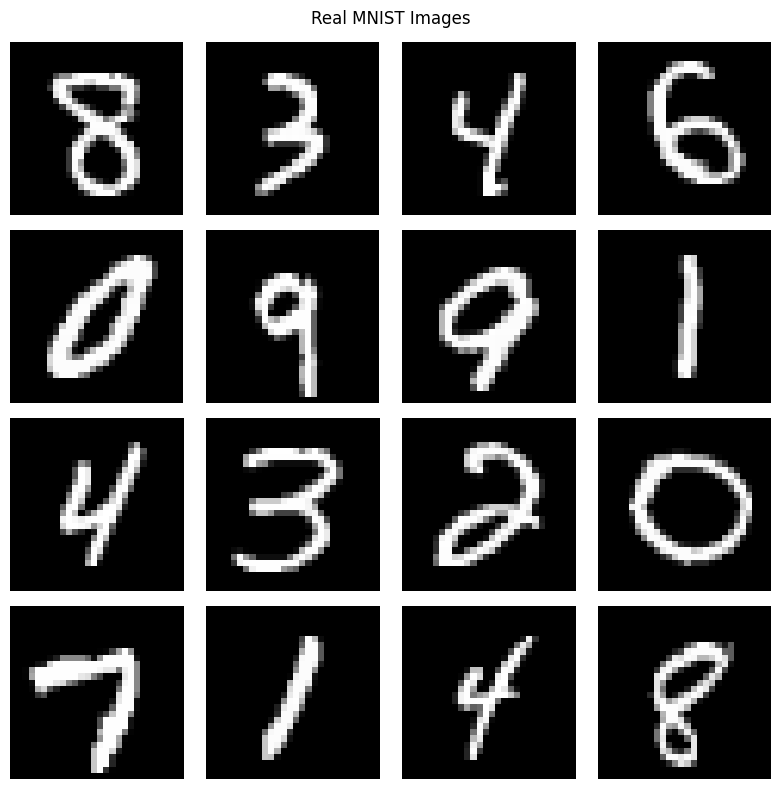

Starting GAN training...
Epoch [1/50], Step [1/469], D_loss: 1.4885, G_loss: 0.9996
Epoch [1/50], Step [101/469], D_loss: 0.9542, G_loss: 0.2795
Epoch [1/50], Step [201/469], D_loss: 0.4791, G_loss: 1.4851
Epoch [1/50], Step [301/469], D_loss: 0.6199, G_loss: 1.2487
Epoch [1/50], Step [401/469], D_loss: 1.5925, G_loss: 4.0028
Epoch [2/50], Step [1/469], D_loss: 0.6437, G_loss: 2.1450
Epoch [2/50], Step [101/469], D_loss: 0.7310, G_loss: 0.9986
Epoch [2/50], Step [201/469], D_loss: 0.4480, G_loss: 1.6716
Epoch [2/50], Step [301/469], D_loss: 0.4781, G_loss: 1.5973
Epoch [2/50], Step [401/469], D_loss: 0.4615, G_loss: 2.1444
Epoch [3/50], Step [1/469], D_loss: 0.6382, G_loss: 0.8990
Epoch [3/50], Step [101/469], D_loss: 0.5383, G_loss: 2.2046
Epoch [3/50], Step [201/469], D_loss: 0.4507, G_loss: 1.9947
Epoch [3/50], Step [301/469], D_loss: 0.5245, G_loss: 1.6838
Epoch [3/50], Step [401/469], D_loss: 0.6293, G_loss: 2.7476
Epoch [4/50], Step [1/469], D_loss: 0.4242, G_loss: 2.4738
Epoch [

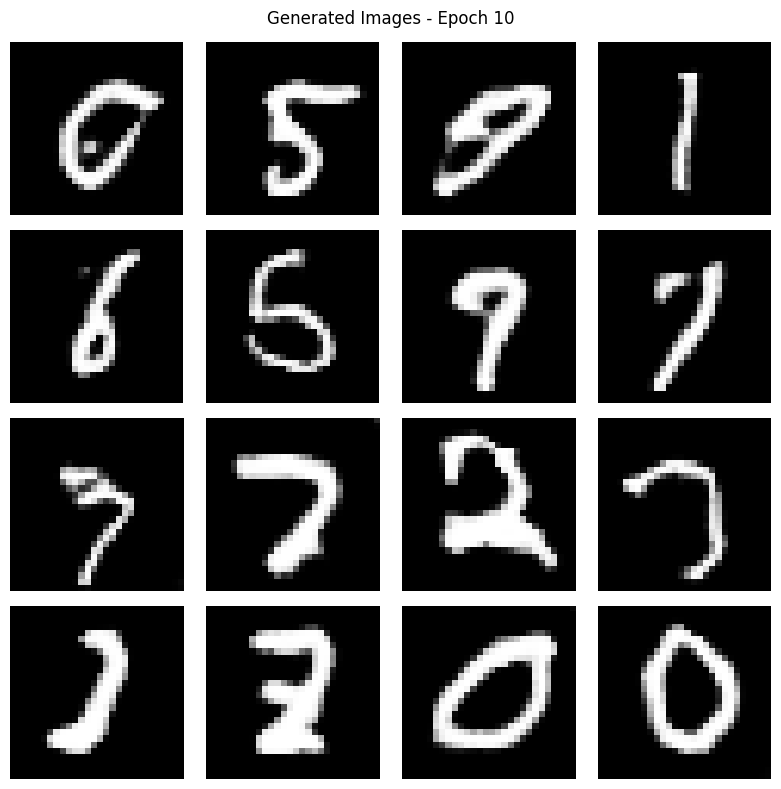

Epoch [11/50], Step [1/469], D_loss: 0.2514, G_loss: 3.0331
Epoch [11/50], Step [101/469], D_loss: 0.2960, G_loss: 4.4586
Epoch [11/50], Step [201/469], D_loss: 0.2828, G_loss: 1.9973
Epoch [11/50], Step [301/469], D_loss: 0.3696, G_loss: 3.4802
Epoch [11/50], Step [401/469], D_loss: 0.2819, G_loss: 2.1857
Epoch [12/50], Step [1/469], D_loss: 0.2333, G_loss: 2.9339
Epoch [12/50], Step [101/469], D_loss: 0.1745, G_loss: 2.8321
Epoch [12/50], Step [201/469], D_loss: 0.2128, G_loss: 2.9714
Epoch [12/50], Step [301/469], D_loss: 0.6302, G_loss: 1.2004
Epoch [12/50], Step [401/469], D_loss: 0.2392, G_loss: 3.5060
Epoch [13/50], Step [1/469], D_loss: 0.2579, G_loss: 2.9658
Epoch [13/50], Step [101/469], D_loss: 0.2809, G_loss: 3.0780
Epoch [13/50], Step [201/469], D_loss: 0.3511, G_loss: 1.6938
Epoch [13/50], Step [301/469], D_loss: 0.2930, G_loss: 3.7684
Epoch [13/50], Step [401/469], D_loss: 0.2041, G_loss: 2.7350
Epoch [14/50], Step [1/469], D_loss: 0.3547, G_loss: 4.6806
Epoch [14/50], S

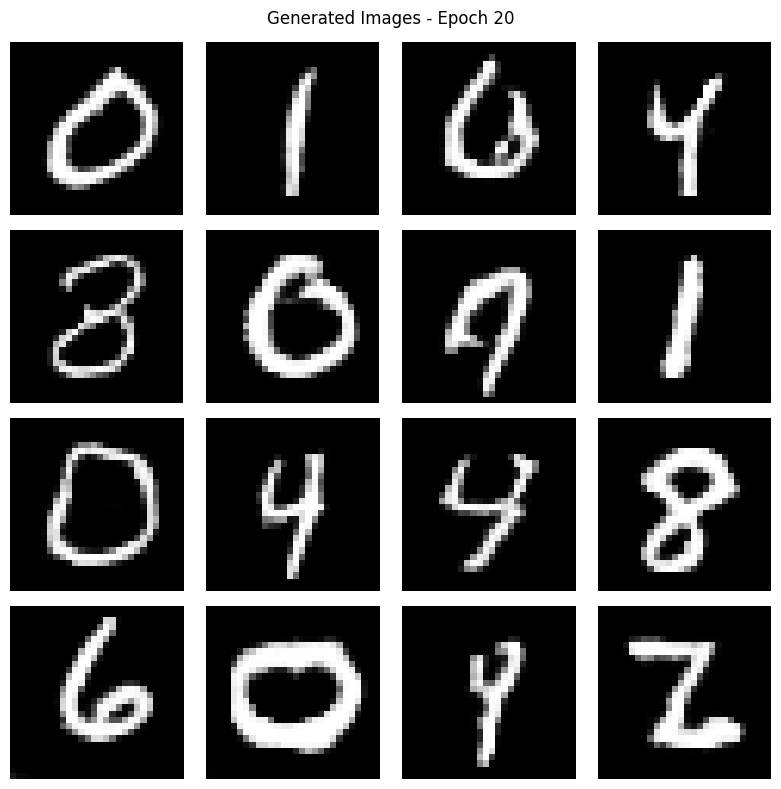

Epoch [21/50], Step [1/469], D_loss: 0.4168, G_loss: 2.9435
Epoch [21/50], Step [101/469], D_loss: 0.4018, G_loss: 1.5479
Epoch [21/50], Step [201/469], D_loss: 0.1862, G_loss: 4.1697
Epoch [21/50], Step [301/469], D_loss: 0.2045, G_loss: 4.4607
Epoch [21/50], Step [401/469], D_loss: 0.1037, G_loss: 4.1224
Epoch [22/50], Step [1/469], D_loss: 0.1362, G_loss: 3.0505
Epoch [22/50], Step [101/469], D_loss: 0.1211, G_loss: 4.2779
Epoch [22/50], Step [201/469], D_loss: 0.1576, G_loss: 3.6232
Epoch [22/50], Step [301/469], D_loss: 0.1595, G_loss: 3.5608
Epoch [22/50], Step [401/469], D_loss: 0.2266, G_loss: 4.3487
Epoch [23/50], Step [1/469], D_loss: 0.1040, G_loss: 3.5356
Epoch [23/50], Step [101/469], D_loss: 0.1054, G_loss: 4.6168
Epoch [23/50], Step [201/469], D_loss: 0.6982, G_loss: 5.5818
Epoch [23/50], Step [301/469], D_loss: 0.0905, G_loss: 3.6542
Epoch [23/50], Step [401/469], D_loss: 0.1547, G_loss: 3.8078
Epoch [24/50], Step [1/469], D_loss: 0.1114, G_loss: 4.2389
Epoch [24/50], S

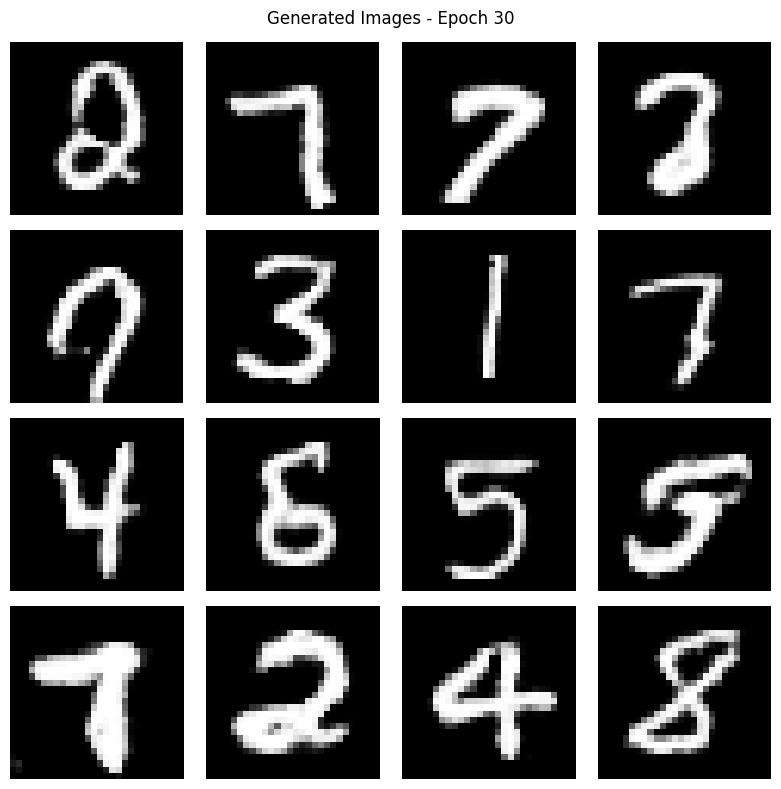

Epoch [31/50], Step [1/469], D_loss: 0.5312, G_loss: 3.0291
Epoch [31/50], Step [101/469], D_loss: 0.1471, G_loss: 3.2513
Epoch [31/50], Step [201/469], D_loss: 0.0990, G_loss: 4.0448
Epoch [31/50], Step [301/469], D_loss: 0.1844, G_loss: 4.5152
Epoch [31/50], Step [401/469], D_loss: 0.1567, G_loss: 3.2486
Epoch [32/50], Step [1/469], D_loss: 1.0840, G_loss: 9.3424
Epoch [32/50], Step [101/469], D_loss: 0.1196, G_loss: 4.5917
Epoch [32/50], Step [201/469], D_loss: 0.4121, G_loss: 1.7990
Epoch [32/50], Step [301/469], D_loss: 0.1167, G_loss: 3.8033
Epoch [32/50], Step [401/469], D_loss: 0.0501, G_loss: 4.2662
Epoch [33/50], Step [1/469], D_loss: 0.2843, G_loss: 4.4552
Epoch [33/50], Step [101/469], D_loss: 0.1421, G_loss: 3.2389
Epoch [33/50], Step [201/469], D_loss: 0.1888, G_loss: 5.0089
Epoch [33/50], Step [301/469], D_loss: 0.4743, G_loss: 4.7583
Epoch [33/50], Step [401/469], D_loss: 0.1697, G_loss: 3.8105
Epoch [34/50], Step [1/469], D_loss: 0.1004, G_loss: 3.9131
Epoch [34/50], S

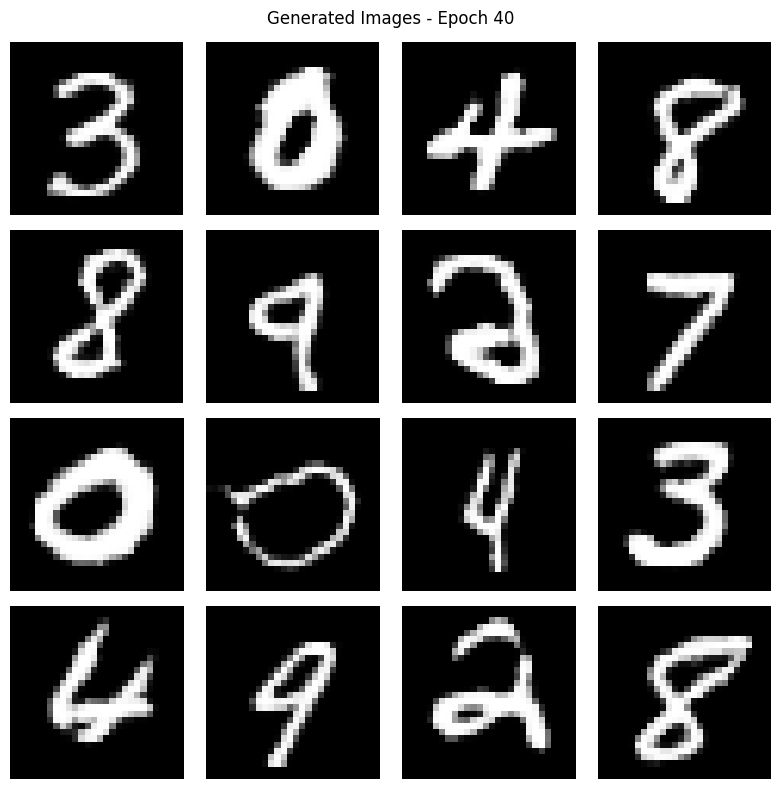

Epoch [41/50], Step [1/469], D_loss: 0.0755, G_loss: 4.4365
Epoch [41/50], Step [101/469], D_loss: 0.0557, G_loss: 4.4692
Epoch [41/50], Step [201/469], D_loss: 0.1408, G_loss: 4.5314
Epoch [41/50], Step [301/469], D_loss: 0.1104, G_loss: 4.2127
Epoch [41/50], Step [401/469], D_loss: 0.6918, G_loss: 7.1206
Epoch [42/50], Step [1/469], D_loss: 0.4759, G_loss: 1.8726
Epoch [42/50], Step [101/469], D_loss: 0.2918, G_loss: 4.2111
Epoch [42/50], Step [201/469], D_loss: 0.1704, G_loss: 3.2260
Epoch [42/50], Step [301/469], D_loss: 0.1663, G_loss: 3.8670
Epoch [42/50], Step [401/469], D_loss: 0.2254, G_loss: 4.8164
Epoch [43/50], Step [1/469], D_loss: 0.1105, G_loss: 3.8637
Epoch [43/50], Step [101/469], D_loss: 0.1239, G_loss: 3.4399
Epoch [43/50], Step [201/469], D_loss: 0.0933, G_loss: 4.7612
Epoch [43/50], Step [301/469], D_loss: 0.0802, G_loss: 4.2880
Epoch [43/50], Step [401/469], D_loss: 0.1260, G_loss: 3.8810
Epoch [44/50], Step [1/469], D_loss: 0.1340, G_loss: 5.2964
Epoch [44/50], S

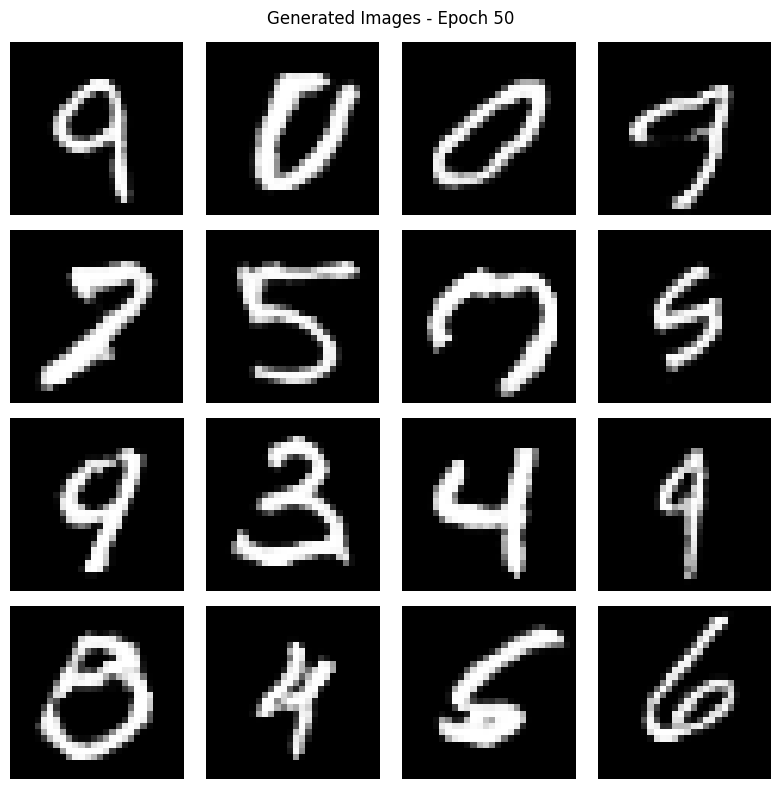

Training completed!


In [14]:
if __name__ == "__main__":
    print("Showing real images first...")
    show_real_images()
    
    print("Starting GAN training...")
    train_gan()
    
    print("Training completed!")